# letra O

In [1]:
import pandas as pd

df_O = pd.read_csv('clientes.csv')
df_O = df_O[df_O['sigla'] == 'O'].copy()
print(f"Total clientes O: {len(df_O)}")
df_O.head()

Total clientes O: 75


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped
52,04586,O,RODA AUTO PECAS LTDA,JARDIM INGA BAIXO,GO,8.0,MAURICIO LIMA DA SILVA,130650.55,106438.46,11486.91,4728,337,57458.00,45703.97,4573.4,2408,139
98,07498,O,FLEX AUTO PECAS E MECANICA EIRELI ME,ALVORADA DO NORTE,GO,8.0,AUGUSTO RAFAEL SAMPAIO BONFIM,28880.15,22620.30,1733.01,797,25,8932.02,6603.39,592.8,242,8
424,15855,O,AMARAL E TEIXEIRA AUTO PECAS ACESSORIOS,QUIRINOPOLIS,GO,8.0,PATRIZIA PATIELLY SILVERIA DE OLIVEIRA,25812.20,18282.07,2782.21,1440,36,6242.26,3976.12,1105.0,363,7
468,16780,O,D2R AUTO PECAS E SERVICOS LTDA,LUZIANIA,GO,8.0,MICHAEL DOUGLAS LIMA DA SILVA,31627.36,22330.25,3855.81,1178,40,16491.36,12231.69,1322.6,400,10
907,23356,O,LUIZ AUTO PECAS LTDA,CRISTALINA,GO,8.0,ADALBERTO MIGUEL SOUZA,13734.35,10252.27,818.62,471,13,2763.69,1903.59,219.6,123,3


In [2]:
import json
with open('_config.json', 'r', encoding='utf-8') as f:
    cfg = json.load(f)

N_DIAS_A = int(cfg['n_dias_a'])
N_DIAS_D = int(cfg['n_dias_d'])

print(f"Período A: {cfg['periodo_a']} — {N_DIAS_A} dias úteis")
print(f"Período D: {cfg['periodo_d']} — {N_DIAS_D} dias úteis")

Período A: Jan-Mar 2026 — 61 dias úteis
Período D: Mai 01-31/2026 — 20 dias úteis


In [3]:
df_O['a_mc_d'] = df_O['a_mc'] / N_DIAS_A
df_O['d_mc_d'] = df_O['d_mc'] / N_DIAS_D
df_O['Δ MC/dia R$'] = df_O['d_mc_d'] - df_O['a_mc_d']

df_queda_O = df_O[df_O['Δ MC/dia R$'] < 0].copy()
df_queda_O = df_queda_O.sort_values('Δ MC/dia R$', ascending=True)

print(f"Total de clientes com queda: {len(df_queda_O)}")
print(f"Queda total de MC: R$ {df_queda_O['Δ MC/dia R$'].sum():.0f}/dia")
df_queda_O.head()

Total de clientes com queda: 31
Queda total de MC: R$ -574/dia


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped,a_mc_d,d_mc_d,Δ MC/dia R$
2922,I7267,O,TNET AUTO PECAS LTDA,GOIANIA - LESTE CIMA,GO,8.0,MANOEL MIGUEL NETO,47588.67,33186.00,6359.86,1241,83,0.00,0.00,0.0,0,0,104.26,0.00,-104.26
1963,I2933,O,ANA CRISTINA DE OLIVEIRA,GOIANESIA,GO,8.0,RAFAEL CAITANO CARDOSO,31240.06,21906.60,4363.94,502,35,1337.15,965.27,135.2,22,2,71.54,6.76,-64.78
1223,27408,O,KADOSH CENTRO AUTOMOTIVO LTDA,APARECIDA DE GOIANIA - SUL DIREITA,GO,8.0,VALQUISLEY SOUSA SILVA,46951.23,35708.66,4471.30,709,95,1989.10,1406.06,217.0,52,5,73.30,10.85,-62.45
2511,I5769,O,MASTER SOLUCOES AUTOMOTIVAS LTDA,GOIANIA - CENTRO OESTE CIMA,GO,8.0,PATRIZIA PATIELLY SILVERIA DE OLIVEIRA,24549.99,17395.37,3337.92,387,88,2909.39,2108.96,379.2,66,12,54.72,18.96,-35.76
1757,I1520,O,IOBERTO ALVES DOS SANTOS JUNIOR LTDA,NOVA VENEZA,GO,8.0,ADALBERTO MIGUEL SOUZA,26905.37,19313.86,3054.88,880,96,1500.58,944.47,310.2,52,10,50.08,15.51,-34.57


In [4]:
total_queda_O = df_queda_O['Δ MC/dia R$'].sum()
meta_80_O = total_queda_O * 0.80

df_queda_O['queda_acum'] = df_queda_O['Δ MC/dia R$'].cumsum()
df_queda_O['pct_acum'] = df_queda_O['queda_acum'] / total_queda_O * 100

grupo_80_O = df_queda_O[df_queda_O['pct_acum'] <= 80].copy()
grupo_20_O = df_queda_O[df_queda_O['pct_acum'] > 80].copy()

print(f"Grupo 80%: {len(grupo_80_O)} clientes — R$ {grupo_80_O['Δ MC/dia R$'].sum():.0f}/dia de queda")
print(f"Grupo 20%: {len(grupo_20_O)} clientes — R$ {grupo_20_O['Δ MC/dia R$'].sum():.0f}/dia de queda")

print(f"Total queda: {total_queda_O:.0f}")

Grupo 80%: 11 clientes — R$ -443/dia de queda
Grupo 20%: 20 clientes — R$ -132/dia de queda
Total queda: -574


In [5]:
print(df_queda_O.columns.tolist())

['codcli', 'sigla', 'nome', 'cidade', 'estado', 'cd_tipocli', 'carteira', 'a_vl', 'a_cmv', 'a_mc', 'a_qtde', 'a_ped', 'd_vl', 'd_cmv', 'd_mc', 'd_qtde', 'd_ped', 'a_mc_d', 'd_mc_d', 'Δ MC/dia R$', 'queda_acum', 'pct_acum']


In [6]:
# Salvar os grupos
grupo_80_O.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_80_atencao_O.csv', index=False)
grupo_20_O.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_20_atencao_O.csv', index=False)

print("\nGrupo 80% — clientes prioritários:")
print(grupo_80_O[['codcli','nome','Δ MC/dia R$','pct_acum']].to_string(index=False))


Grupo 80% — clientes prioritários:
codcli                                     nome  Δ MC/dia R$  pct_acum
 I7267                     TNET AUTO PECAS LTDA      -104.26 18.150166
 I2933                 ANA CRISTINA DE OLIVEIRA       -64.78 29.427432
 27408            KADOSH CENTRO AUTOMOTIVO LTDA       -62.45 40.299079
 I5769         MASTER SOLUCOES AUTOMOTIVAS LTDA       -35.76 46.524381
 I1520     IOBERTO ALVES DOS SANTOS JUNIOR LTDA       -34.57 52.542520
 I6087                       KD AUTO PECAS LTDA       -29.39 57.658897
 I1891                SMM PECAS E SERVICOS LTDA       -27.32 62.414916
 I2952 AUTO CARS EXPRESS CENTRO AUTOMOTIVO LTDA       -23.39 66.486778
 24237                   PACOTAO DAS PECAS LTDA       -20.92 70.128649
 I5887      ALLYF ANTONIO ALVES DOS SANTOS LTDA       -20.35 73.671292
 I1937                    OPEN AUTO CENTER LTDA       -19.52 77.069443


In [7]:
# USANDO CLI_FORN
cf_O = pd.read_csv('cli_forn.csv')
cf_O['Δ vl_d'] = cf_O['d_vl_d'] - cf_O['a_vl_d']
cf_O['Δ vl_pct'] = (cf_O['Δ vl_d'] / cf_O['a_vl_d'].replace(0, float('nan'))) * 100

# Filtra só os 11 clientes do grupo 80%
codigos_80_O = grupo_80_O['codcli'].astype(str).tolist()  # ← mudou aqui
cf_80_O = cf_O[cf_O['codcli'].astype(str).isin(codigos_80_O)].copy()

print(f"Registros encontrados no cli_forn: {len(cf_80_O)}")
cf_80_O.head()

Registros encontrados no cli_forn: 580


,codcli,sigla,nome,codfor,fornecedor,fantasia,a_vl_d,a_cmv_d,a_mc_d,a_qtde,d_vl_d,d_cmv_d,d_mc_d,d_qtde,Δ vl_d,Δ vl_pct
17924,24237,O,PACOTAO DAS PECAS LTDA,2,3RHO INTERRUPTORES AUTOMOTIVOS LTDA,3RHO,0.84,0.60,0.15,1,5.47,4.02,0.84,2,4.63,551.190476
17925,24237,O,PACOTAO DAS PECAS LTDA,55,OSPINA IND DE AUTO PECAS LTDA,OSPINA,0.96,0.59,0.26,1,0.00,0.00,0.00,0,-0.96,-100.000000
17926,24237,O,PACOTAO DAS PECAS LTDA,76,EDANTI IND COM PECAS PARA AUTOS LTDA,EDANTI,0.21,0.12,0.07,2,0.00,0.00,0.00,0,-0.21,-100.000000
17927,24237,O,PACOTAO DAS PECAS LTDA,124,ZEN S.A INDUSTRIA METALURGICA,ZEN,39.01,28.90,5.95,49,28.49,20.96,3.68,10,-10.52,-26.967444
17928,24237,O,PACOTAO DAS PECAS LTDA,150,INDUSTRIA MARILIA DE AUTO PECAS S.A,MARILIA,12.46,8.56,2.50,11,1.21,0.76,0.30,1,-11.25,-90.288925


In [8]:
# Para cada cliente, calcula média e desvio padrão das quedas por fornecedor
resumo = []
for codcli, grupo in cf_80_O.groupby('codcli'):
    nome = grupo['nome'].iloc[0]
    
    # Só fornecedores que tinham venda antes
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    quedas = sub['Δ vl_pct'].dropna()
    
    if len(quedas) < 2:
        continue
    
    media = quedas.mean()
    desvio = quedas.std()
    cv = abs(desvio / media) if media != 0 else float('nan')
    n_fornecedores = len(sub)
    
    # Zeraram = só dos que tinham venda antes e agora estão em 0
    n_zerou = (sub['d_vl_d'] == 0).sum()
    
    resumo.append({
        'codcli': codcli,
        'Cliente': nome,
        'N fornecedores': n_fornecedores,
        'Queda média %': round(media, 1),
        'Desvio padrão': round(desvio, 1),
        'CV': round(cv, 2),
        'Zeraram': n_zerou,
        'Tipo': 'Normalizada' if cv < 0.5 else 'Concentrada'
    })

df_resumo = pd.DataFrame(resumo).sort_values('CV')
print(df_resumo.to_string(index=False))

codcli                                  Cliente  N fornecedores  Queda média %  Desvio padrão     CV  Zeraram        Tipo
 I1937                    OPEN AUTO CENTER LTDA              29         -100.0            0.0   0.00       29 Normalizada
 I7267                     TNET AUTO PECAS LTDA              75         -100.0            0.0   0.00       75 Normalizada
 27408            KADOSH CENTRO AUTOMOTIVO LTDA              54          -76.1           55.7   0.73       38 Concentrada
 I2933                 ANA CRISTINA DE OLIVEIRA              49          -80.7           63.3   0.78       42 Concentrada
 I1891                SMM PECAS E SERVICOS LTDA              49          -67.6           71.8   1.06       34 Concentrada
 I6087                       KD AUTO PECAS LTDA              47          -56.6           74.8   1.32       30 Concentrada
 I5887      ALLYF ANTONIO ALVES DOS SANTOS LTDA              51          -45.8           91.6   2.00       31 Concentrada
 I1520     IOBERTO ALVES

In [9]:
# Troca o código aqui para ver um cliente específico
# Deixa None para ver todos
FILTRO_CODCLI = '27408'

for codcli, grupo in cf_80_O.groupby('codcli'):
    if FILTRO_CODCLI and str(codcli) != str(FILTRO_CODCLI):
        continue
    nome = grupo['nome'].iloc[0]
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    sub = sub.sort_values('Δ vl_pct')
    
    print(f"\n{'='*60}")
    print(f"{nome} ({codcli})")
    print(f"Queda média: {sub['Δ vl_pct'].mean():.1f}% | Desvio: {sub['Δ vl_pct'].std():.1f} | CV: {abs(sub['Δ vl_pct'].std()/sub['Δ vl_pct'].mean()):.2f} | Fornecedores: {len(sub)}")
    print(f"{'Fornecedor':<25} {'Fat Antes':>12} {'Fat Atual':>12} {'Δ %':>10} {'Status'}")
    print('-'*70)
    for _, row in sub.iterrows():
        if row['d_vl_d'] == 0:
            status = '🔴 Zerou'
        elif row['a_vl_d'] == 0:
            status = '🆕 Novo'
        elif row['Δ vl_pct'] <= -10:
            status = '🟡 Caiu'
        elif row['Δ vl_pct'] >= 10:
            status = '🟢 Aumentou'
        else:
            status = '⚪ Estável'
        print(f"{str(row['fantasia']):<25} {row['a_vl_d']:>12.2f} {row['d_vl_d']:>12.2f} {row['Δ vl_pct']:>10.1f}% {status}")


KADOSH CENTRO AUTOMOTIVO LTDA (27408)
Queda média: -76.1% | Desvio: 55.7 | CV: 0.73 | Fornecedores: 54
Fornecedor                   Fat Antes    Fat Atual        Δ % Status
----------------------------------------------------------------------
3RHO                              2.28         0.00     -100.0% 🔴 Zerou
MTA                               1.53         0.00     -100.0% 🔴 Zerou
ROLTENS                           1.94         0.00     -100.0% 🔴 Zerou
BOSCH                            17.25         0.00     -100.0% 🔴 Zerou
SUN ELETRI                        2.44         0.00     -100.0% 🔴 Zerou
VALEO                             5.33         0.00     -100.0% 🔴 Zerou
RAINHA DA                         0.17         0.00     -100.0% 🔴 Zerou
FLORIO                            8.28         0.00     -100.0% 🔴 Zerou
TSA                               0.79         0.00     -100.0% 🔴 Zerou
RADNAQ                            0.70         0.00     -100.0% 🔴 Zerou
DPL                               2

In [10]:
with pd.ExcelWriter('analise_clientes_80_O.xlsx') as writer:
    # Aba resumo
    df_resumo.to_excel(writer, sheet_name='Resumo', index=False)
    
    # Uma aba por cliente
    for codcli, grupo in cf_80_O.groupby('codcli'):
        nome = grupo['nome'].iloc[0][:25]  # max 25 chars no nome da aba
        sub = grupo[grupo['a_vl_d'] > 0].copy()
        sub = sub.sort_values('Δ vl_pct')
        sub['Status'] = sub.apply(
            lambda r: 'Zerou' if r['d_vl_d'] == 0 else ('Novo' if r['a_vl_d'] == 0 else ''), axis=1
        )
        sub[['fantasia','a_vl_d','d_vl_d','Δ vl_pct','Status']].to_excel(
            writer, sheet_name=nome, index=False
        )

In [11]:
from collections import Counter

clientes_concentrados_O = df_resumo[df_resumo['Tipo'] == 'Concentrada']['codcli'].astype(str).tolist()

# Para cada cliente concentrado, pega os fornecedores que zeraram
fornecedores_zerados = {}
for cod in clientes_concentrados_O:
    sub = cf_80_O[cf_80_O['codcli'].astype(str) == cod].copy()
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    fornecedores_zerados[cod] = set(zerados)

# Conta em quantos clientes cada fornecedor aparece zerado
todos_zerados = [f for zerados in fornecedores_zerados.values() for f in zerados]
contagem = Counter(todos_zerados)

# Só os que aparecem em mais de 1 cliente
em_comum_O = {k: v for k, v in contagem.items() if v > 1}
df_comum_O = pd.DataFrame(em_comum_O.items(), columns=['Fornecedor', 'Qtd Clientes']).sort_values('Qtd Clientes', ascending=False)

C:\Users\priscila.marques\AppData\Local\Temp\ipykernel_26848\50909316.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_forn, rotation=45, ha='right', fontsize=9)


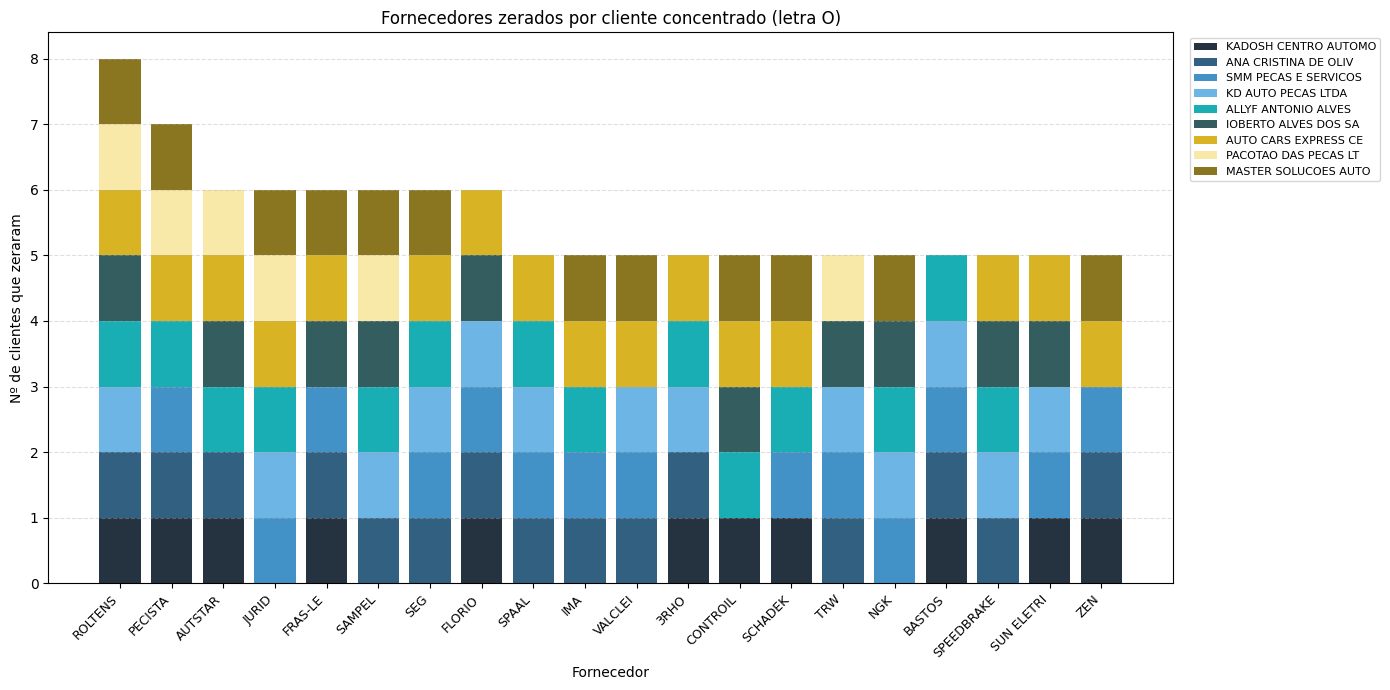

In [13]:
import matplotlib.pyplot as plt
import numpy as np

top_forn = df_comum_O.head(20)['Fornecedor'].tolist()

# Azuis e amarelos bem distintos
cores_lista = [
    '#0d1b2a',  # azul quase preto
    '#1b4f72',  # azul escuro
    '#2e86c1',  # azul médio
    '#5dade2',  # azul claro
    '#00a5ac',  # amarelo forte
    "#1d4b4d",  # amarelo alaranjado
    '#d4ac0d',  # amarelo dourado
    '#f9e79f',  # amarelo bem claro
    '#7d6608',  # amarelo escuro
]
cores_clientes = {cod: cor for cod, cor in zip(clientes_concentrados_O, cores_lista)}

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(top_forn))
for cod in clientes_concentrados_O:
    sub = cf_80_O[cf_80_O['codcli'].astype(str) == cod]
    nome = sub['nome'].iloc[0][:20]
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    valores = [1 if f in zerados else 0 for f in top_forn]
    
    ax.bar(top_forn, valores, bottom=bottom,
           color=cores_clientes[cod], label=nome, alpha=0.9)
    bottom += np.array(valores)

ax.set_xlabel("Fornecedor")
ax.set_ylabel("Nº de clientes que zeraram")
ax.set_title("Fornecedores zerados por cliente concentrado (letra O)", fontsize=12)
ax.set_xticklabels(top_forn, rotation=45, ha='right', fontsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Letra Q

In [26]:
import pandas as pd

df_Q = pd.read_csv('clientes.csv')
df_Q = df_Q[df_Q['sigla'] == 'Q'].copy()
print(f"Total clientes Q: {len(df_Q)}")
df_Q.head()

Total clientes Q: 19


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped
185,10537,Q,TOTAL AUTO PECAS EIRELI,NOVO GAMA,GO,8.0,VINICIUS GONCALVES MARTINS,23871.81,18828.41,3167.73,980,34,8157.95,6488.21,1344.8,483,20
1053,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,QUIRINOPOLIS,GO,8.0,FELIPE RIBEIRO DE JESUS,35230.49,25301.65,3383.67,1041,49,9522.97,6705.39,863.6,80,7
1259,27566,Q,WILMAR SOUSA DO NASCIMENTO ME,GOIANIA - 3KM CIMA,GO,8.0,MATHEUS RIBEIRO MIGUEL,11768.64,8038.70,469.09,671,20,449.41,300.99,21.6,25,3
1765,I1539,Q,DONIZETE MEIRA TEIXEIRA LTDA,JUSSARA,GO,8.0,MANOEL MIGUEL NETO,16790.97,12117.23,1381.04,945,27,6093.32,4331.39,455.2,241,7
1780,I1602,Q,BORGES OLIVEIRA PECAS PARA VEICULOS LTDA,CAMPINORTE,GO,8.0,MATHEUS RIBEIRO MIGUEL,10830.49,7371.64,1469.49,319,7,9190.02,6039.26,1299.4,241,11


In [27]:
import json
with open('_config.json', 'r', encoding='utf-8') as f:
    cfg = json.load(f)

N_DIAS_A = int(cfg['n_dias_a'])
N_DIAS_D = int(cfg['n_dias_d'])

print(f"Período A: {cfg['periodo_a']} — {N_DIAS_A} dias úteis")
print(f"Período D: {cfg['periodo_d']} — {N_DIAS_D} dias úteis")

Período A: Jan-Mar 2026 — 61 dias úteis
Período D: Mai 01-31/2026 — 20 dias úteis


In [28]:
df_Q['a_mc_d'] = df_Q['a_mc'] / N_DIAS_A
df_Q['d_mc_d'] = df_Q['d_mc'] / N_DIAS_D
df_Q['Δ MC/dia R$'] = df_Q['d_mc_d'] - df_Q['a_mc_d']

df_queda_Q = df_Q[df_Q['Δ MC/dia R$'] < 0].copy()
df_queda_Q = df_queda_Q.sort_values('Δ MC/dia R$', ascending=True)

print(f"Total de clientes com queda: {len(df_queda_Q)}")
print(f"Queda total de MC: R$ {df_queda_Q['Δ MC/dia R$'].sum():.0f}/dia")
df_queda_Q.head()

Total de clientes com queda: 9


Queda total de MC: R$ -67/dia


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped,a_mc_d,d_mc_d,Δ MC/dia R$
1975,I2964,Q,GERLANDIA MARIA GOMES DA SILVA E CIA LTD,MOZARLANDIA,GO,8.0,MATHEUS RIBEIRO MIGUEL,12118.73,8242.80,1567.09,292,12,869.63,592.73,110.6,23,4,25.69,5.53,-20.16
1053,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,QUIRINOPOLIS,GO,8.0,FELIPE RIBEIRO DE JESUS,35230.49,25301.65,3383.67,1041,49,9522.97,6705.39,863.6,80,7,55.47,43.18,-12.29
1896,I2621,Q,SOPEL SO PECAS ELETRICAS LTDA,NIQUELANDIA,GO,8.0,MANOEL MIGUEL NETO,51978.60,38198.56,4514.61,2384,20,12086.75,8593.04,1301.8,275,10,74.01,65.09,-8.92
2181,I4352,Q,FARIAS AUTO CENTER LTDA,VIANOPOLIS,GO,8.0,KAIO VINICIUS VIEIRA DE JESUS,3056.90,2162.09,433.10,67,5,0.00,0.00,0.0,0,0,7.10,0.00,-7.10
1259,27566,Q,WILMAR SOUSA DO NASCIMENTO ME,GOIANIA - 3KM CIMA,GO,8.0,MATHEUS RIBEIRO MIGUEL,11768.64,8038.70,469.09,671,20,449.41,300.99,21.6,25,3,7.69,1.08,-6.61


In [29]:
total_queda_Q = df_queda_Q['Δ MC/dia R$'].sum()
meta_80_Q = total_queda_Q * 0.80

df_queda_Q['queda_acum'] = df_queda_Q['Δ MC/dia R$'].cumsum()
df_queda_Q['pct_acum'] = df_queda_Q['queda_acum'] / total_queda_Q * 100

grupo_80_Q = df_queda_Q[df_queda_Q['pct_acum'] <= 80].copy()
grupo_20_Q = df_queda_Q[df_queda_Q['pct_acum'] > 80].copy()

print(f"Grupo 80%: {len(grupo_80_Q)} clientes — R$ {grupo_80_Q['Δ MC/dia R$'].sum():.0f}/dia de queda")
print(f"Grupo 20%: {len(grupo_20_Q)} clientes — R$ {grupo_20_Q['Δ MC/dia R$'].sum():.0f}/dia de queda")

print(f"Total queda: {total_queda_Q:.0f}")

Grupo 80%: 4 clientes — R$ -48/dia de queda
Grupo 20%: 5 clientes — R$ -18/dia de queda
Total queda: -67


In [30]:
# Salvar os grupos
grupo_80_Q.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_80_atencao_Q.csv', index=False)
grupo_20_Q.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_20_atencao_Q.csv', index=False)

print("\nGrupo 80% — clientes prioritários:")
print(grupo_80_Q[['codcli','nome','Δ MC/dia R$','pct_acum']].to_string(index=False))


Grupo 80% — clientes prioritários:
codcli                                     nome  Δ MC/dia R$  pct_acum
 I2964 GERLANDIA MARIA GOMES DA SILVA E CIA LTD       -20.16 30.265726
 24165          AUTO ELETRICA QUIRINOPOLIS LTDA       -12.29 48.716409
 I2621            SOPEL SO PECAS ELETRICAS LTDA        -8.92 62.107792
 I4352                  FARIAS AUTO CENTER LTDA        -7.10 72.766852


In [31]:
# USANDO CLI_FORN
cf_Q = pd.read_csv('cli_forn.csv')
cf_Q['Δ vl_d'] = cf_Q['d_vl_d'] - cf_Q['a_vl_d']
cf_Q['Δ vl_pct'] = (cf_Q['Δ vl_d'] / cf_Q['a_vl_d'].replace(0, float('nan'))) * 100

# Filtra só os 11 clientes do grupo 80%
codigos_80_Q = grupo_80_Q['codcli'].astype(str).tolist()  # ← mudou aqui
cf_80_Q = cf_Q[cf_Q['codcli'].astype(str).isin(codigos_80_Q)].copy()

print(f"Registros encontrados no cli_forn: {len(cf_80_Q)}")
cf_80_Q.head()

Registros encontrados no cli_forn: 139


,codcli,sigla,nome,codfor,fornecedor,fantasia,a_vl_d,a_cmv_d,a_mc_d,a_qtde,d_vl_d,d_cmv_d,d_mc_d,d_qtde,Δ vl_d,Δ vl_pct
17446,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,2,3RHO INTERRUPTORES AUTOMOTIVOS LTDA,3RHO,1.33,1.01,0.17,2,0.00,0.00,0.00,0,-1.33,-100.000000
17447,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,124,ZEN S.A INDUSTRIA METALURGICA,ZEN,45.50,36.35,2.64,34,97.03,71.90,5.07,12,51.53,113.252747
17448,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,150,INDUSTRIA MARILIA DE AUTO PECAS S.A,MARILIA,5.07,3.95,0.21,3,0.00,0.00,0.00,0,-5.07,-100.000000
17449,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,253,GATES DO BRASIL IND. E COMERCIO LTDA,GATES,18.60,13.10,3.18,7,0.00,0.00,0.00,0,-18.60,-100.000000
17450,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,254,UNIFAP INDUSTRIA METALURGICA LTDA,UNIFAP,7.60,5.68,0.18,20,38.88,27.26,2.58,7,31.28,411.578947


In [32]:
# Para cada cliente, calcula média e desvio padrão das quedas por fornecedor
resumo = []
for codcli, grupo in cf_80_Q.groupby('codcli'):
    nome = grupo['nome'].iloc[0]
    
    # Só fornecedores que tinham venda antes
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    quedas = sub['Δ vl_pct'].dropna()
    
    if len(quedas) < 2:
        continue
    
    media = quedas.mean()
    desvio = quedas.std()
    cv = abs(desvio / media) if media != 0 else float('nan')
    n_fornecedores = len(sub)
    
    # Zeraram = só dos que tinham venda antes e agora estão em 0
    n_zerou = (sub['d_vl_d'] == 0).sum()
    
    resumo.append({
        'codcli': codcli,
        'Cliente': nome,
        'N fornecedores': n_fornecedores,
        'Queda média %': round(media, 1),
        'Desvio padrão': round(desvio, 1),
        'CV': round(cv, 2),
        'Zeraram': n_zerou,
        'Tipo': 'Normalizada' if cv < 0.5 else 'Concentrada'
    })

df_resumo_Q = pd.DataFrame(resumo).sort_values('CV')
print(df_resumo_Q.to_string(index=False))

codcli                                  Cliente  N fornecedores  Queda média %  Desvio padrão   CV  Zeraram        Tipo
 I4352                  FARIAS AUTO CENTER LTDA              14         -100.0            0.0 0.00       14 Normalizada
 I2621            SOPEL SO PECAS ELETRICAS LTDA              34          -64.7           47.9 0.74       17 Concentrada
 I2964 GERLANDIA MARIA GOMES DA SILVA E CIA LTD              33          -67.3          127.5 1.89       28 Concentrada
 24165          AUTO ELETRICA QUIRINOPOLIS LTDA              49          -27.9          255.2 9.15       38 Concentrada


In [33]:
# Troca o código aqui para ver um cliente específico
# Deixa None para ver todos
FILTRO_CODCLI = 'I4352'

for codcli, grupo in cf_80_Q.groupby('codcli'):
    if FILTRO_CODCLI and str(codcli) != str(FILTRO_CODCLI):
        continue
    nome = grupo['nome'].iloc[0]
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    sub = sub.sort_values('Δ vl_pct')
    
    print(f"\n{'='*60}")
    print(f"{nome} ({codcli})")
    print(f"Queda média: {sub['Δ vl_pct'].mean():.1f}% | Desvio: {sub['Δ vl_pct'].std():.1f} | CV: {abs(sub['Δ vl_pct'].std()/sub['Δ vl_pct'].mean()):.2f} | Fornecedores: {len(sub)}")
    print(f"{'Fornecedor':<25} {'Fat Antes':>12} {'Fat Atual':>12} {'Δ %':>10} {'Status'}")
    print('-'*70)
    for _, row in sub.iterrows():
        if row['d_vl_d'] == 0:
            status = '🔴 Zerou'
        elif row['a_vl_d'] == 0:
            status = '🆕 Novo'
        elif row['Δ vl_pct'] <= -10:
            status = '🟡 Caiu'
        elif row['Δ vl_pct'] >= 10:
            status = '🟢 Aumentou'
        else:
            status = '⚪ Estável'
        print(f"{str(row['fantasia']):<25} {row['a_vl_d']:>12.2f} {row['d_vl_d']:>12.2f} {row['Δ vl_pct']:>10.1f}% {status}")


FARIAS AUTO CENTER LTDA (I4352)
Queda média: -100.0% | Desvio: 0.0 | CV: 0.00 | Fornecedores: 14
Fornecedor                   Fat Antes    Fat Atual        Δ % Status
----------------------------------------------------------------------
GATES                             1.52         0.00     -100.0% 🔴 Zerou
PERFECT                          16.34         0.00     -100.0% 🔴 Zerou
WEGA                              2.52         0.00     -100.0% 🔴 Zerou
HIPPER FRE                        1.56         0.00     -100.0% 🔴 Zerou
METAL LEVE                        0.90         0.00     -100.0% 🔴 Zerou
SAMPEL                            1.03         0.00     -100.0% 🔴 Zerou
OR PARTS                          5.01         0.00     -100.0% 🔴 Zerou
APLIC                             1.27         0.00     -100.0% 🔴 Zerou
SCHADEK                           2.65         0.00     -100.0% 🔴 Zerou
VOX                               0.92         0.00     -100.0% 🔴 Zerou
ROLTENS                           4.00   

In [34]:
with pd.ExcelWriter('analise_clientes_80_Q.xlsx') as writer:
    # Aba resumo
    df_resumo_Q.to_excel(writer, sheet_name='Resumo', index=False)
    
    # Uma aba por cliente
    for codcli, grupo in cf_80_Q.groupby('codcli'):
        nome = grupo['nome'].iloc[0][:25]  # max 25 chars no nome da aba
        sub = grupo[grupo['a_vl_d'] > 0].copy()
        sub = sub.sort_values('Δ vl_pct')
        sub['Status'] = sub.apply(
            lambda r: 'Zerou' if r['d_vl_d'] == 0 else ('Novo' if r['a_vl_d'] == 0 else ''), axis=1
        )
        sub[['fantasia','a_vl_d','d_vl_d','Δ vl_pct','Status']].to_excel(
            writer, sheet_name=nome, index=False
        )

In [35]:
from collections import Counter

clientes_concentrados_Q = df_resumo_Q[df_resumo_Q['Tipo'] == 'Concentrada']['codcli'].astype(str).tolist()

# Para cada cliente concentrado, pega os fornecedores que zeraram
fornecedores_zerados = {}
for cod in clientes_concentrados_Q:
    sub = cf_80_Q[cf_80_Q['codcli'].astype(str) == cod].copy()
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    fornecedores_zerados[cod] = set(zerados)

# Conta em quantos clientes cada fornecedor aparece zerado
todos_zerados = [f for zerados in fornecedores_zerados.values() for f in zerados]
contagem = Counter(todos_zerados)

# Só os que aparecem em mais de 1 cliente
em_comum_Q = {k: v for k, v in contagem.items() if v > 1}
df_comum_Q = pd.DataFrame(em_comum_Q.items(), columns=['Fornecedor', 'Qtd Clientes']).sort_values('Qtd Clientes', ascending=False)

C:\Users\priscila.marques\AppData\Local\Temp\ipykernel_26848\3710599379.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_forn_Q, rotation=45, ha='right', fontsize=9)


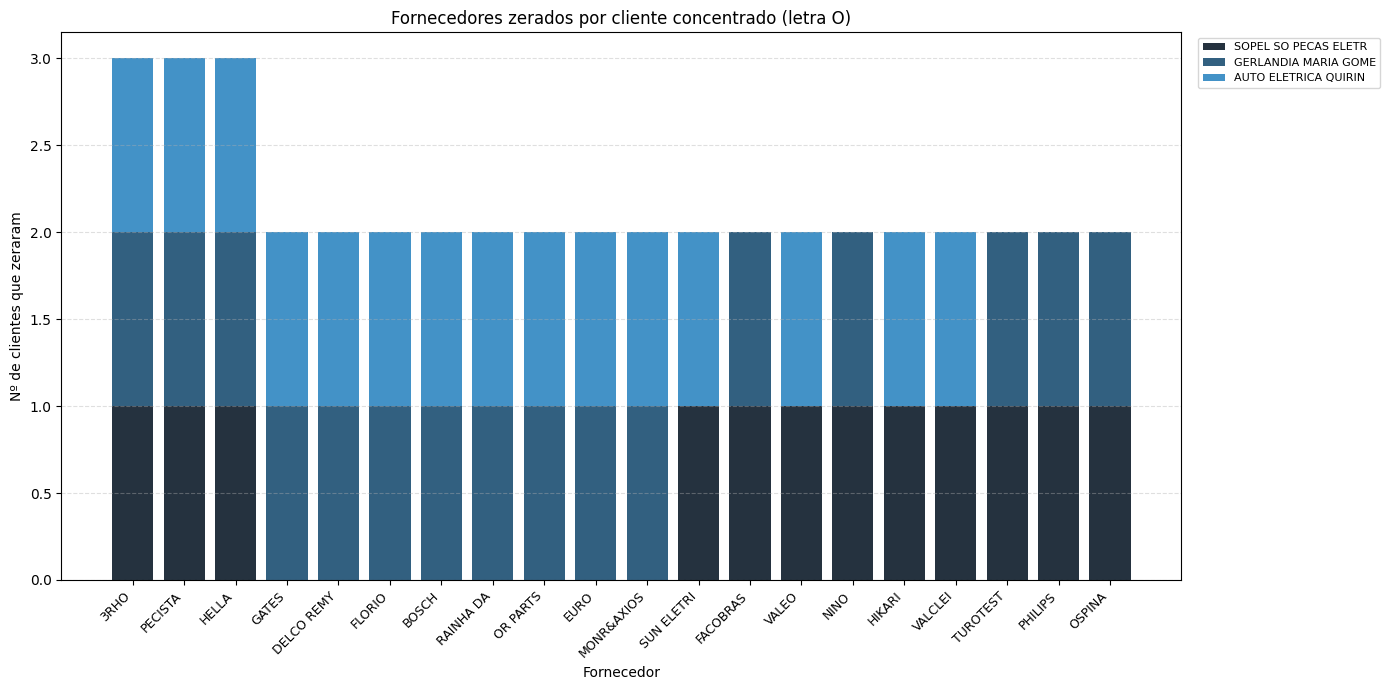

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

top_forn_Q = df_comum_Q.head(20)['Fornecedor'].tolist()

# Azuis e amarelos bem distintos
cores_lista = [
    '#0d1b2a',  # azul quase preto
    '#1b4f72',  # azul escuro
    '#2e86c1',  # azul médio
    '#5dade2',  # azul claro
    '#00a5ac',  # amarelo forte
    "#1d4b4d",  # amarelo alaranjado
    '#d4ac0d',  # amarelo dourado
    '#f9e79f',  # amarelo bem claro
    '#7d6608',  # amarelo escuro
]
cores_clientes = {cod: cor for cod, cor in zip(clientes_concentrados_Q, cores_lista)}

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(top_forn_Q))
for cod in clientes_concentrados_Q:
    sub = cf_80_Q[cf_80_Q['codcli'].astype(str) == cod]
    nome = sub['nome'].iloc[0][:20]
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    valores = [1 if f in zerados else 0 for f in top_forn_Q]
    
    ax.bar(top_forn_Q, valores, bottom=bottom,
           color=cores_clientes[cod], label=nome, alpha=0.9)
    bottom += np.array(valores)

ax.set_xlabel("Fornecedor")
ax.set_ylabel("Nº de clientes que zeraram")
ax.set_title("Fornecedores zerados por cliente concentrado (letra O)", fontsize=12)
ax.set_xticklabels(top_forn_Q, rotation=45, ha='right', fontsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# letra K

In [49]:
import pandas as pd

df_K = pd.read_csv('clientes.csv')
df_K = df_K[df_K['sigla'] == 'K'].copy()
print(f"Total clientes K: {len(df_K)}")
df_K.head()

Total clientes K: 1742


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped
3,00346,K,HELIO AUTO CAR ME,PLANALTINA GO OESTE,GO,8.0,GETULIO CARVALHO PEREIRA,3492.94,2362.15,324.52,448,4,723.60,642.24,55.0,62,4
4,00396,K,SEBASTIAO DE SOUZA CARVALHO SOBRINHO,JARDIM INGA BAIXO,GO,8.0,MAURICIO LIMA DA SILVA,45848.12,36252.15,6638.02,3180,387,14710.79,11527.81,2647.2,867,144
5,00415,K,FENIX AUTO PECAS LTDA EPP,VALPARAISO CIMA,GO,8.0,VINICIUS GONCALVES MARTINS,15209.95,12507.41,2521.13,804,83,3234.37,2847.30,538.0,217,21
6,00423,K,MEIRELLES E LEITE LTDA *,LUZIANIA,GO,8.0,MICHAEL DOUGLAS LIMA DA SILVA,23486.02,19923.41,3292.78,1139,76,7075.43,6256.83,900.2,619,26
7,00455,K,NAILTON CORREIA DA SILVA,PADRE BERNARDO,GO,8.0,MANOEL MIGUEL NETO,41621.34,29242.35,3743.57,1668,16,11853.16,7896.48,1419.6,427,5


In [50]:
import json
with open('_config.json', 'r', encoding='utf-8') as f:
    cfg = json.load(f)

N_DIAS_A = int(cfg['n_dias_a'])
N_DIAS_D = int(cfg['n_dias_d'])

print(f"Período A: {cfg['periodo_a']} — {N_DIAS_A} dias úteis")
print(f"Período D: {cfg['periodo_d']} — {N_DIAS_D} dias úteis")

Período A: Jan-Mar 2026 — 61 dias úteis
Período D: Mai 01-31/2026 — 20 dias úteis


In [51]:
df_K['a_mc_d'] = df_K['a_mc'] / N_DIAS_A
df_K['d_mc_d'] = df_K['d_mc'] / N_DIAS_D
df_K['Δ MC/dia R$'] = df_K['d_mc_d'] - df_K['a_mc_d']

df_queda_K = df_K[df_K['Δ MC/dia R$'] < 0].copy()
df_queda_K = df_queda_K.sort_values('Δ MC/dia R$', ascending=True)

print(f"Total de clientes com queda: {len(df_queda_K)}")
print(f"Queda total de MC: R$ {df_queda_K['Δ MC/dia R$'].sum():.0f}/dia")
df_queda_K.head()

Total de clientes com queda: 909
Queda total de MC: R$ -10665/dia


,codcli,sigla,nome,cidade,estado,cd_tipocli,carteira,a_vl,a_cmv,a_mc,a_qtde,a_ped,d_vl,d_cmv,d_mc,d_qtde,d_ped,a_mc_d,d_mc_d,Δ MC/dia R$
698,20527,K,CLEIBSON LIMA DA ROCHA,SANTO ANTONIO,GO,8.0,WILDEMBERG DE MELO MONTELES,65265.28,53405.49,11580.24,1229,287,0.00,0.00,0.0,0,0,189.84,0.00,-189.84
2044,I3875,K,ANDERSON DE JESUS SANTOS,GOIANIA - NORTE ESQUERDA,GO,8.0,AUGUSTO RAFAEL SAMPAIO BONFIM,85331.36,60492.59,11031.85,1665,196,0.00,0.00,0.0,0,0,180.85,0.00,-180.85
2947,I7445,K,WIGOR ROSA RIBEIRO,QUIRINOPOLIS,GO,8.0,HUMBERTO JOSE DE OLIVEIRA,106786.80,77572.11,11231.93,2607,87,1488.54,1002.78,119.4,30,1,184.13,5.97,-178.16
631,19643,K,ADENILDO ANTONIO MARCELINO,ALTO PARAISO DE GOIAS,GO,8.0,ALEXSANDER PHABLO SANTOS DE ALMEIDA,69970.73,52586.71,9684.97,1445,111,0.00,0.00,0.0,0,0,158.77,0.00,-158.77
917,23403,K,ECR LTDA,NOVO GAMA,GO,8.0,DENILSON DA SILVA MORAIS,50469.16,42028.10,9616.04,817,185,0.00,0.00,0.0,0,0,157.64,0.00,-157.64


In [52]:
total_queda_K = df_queda_K['Δ MC/dia R$'].sum()
meta_80_K = total_queda_K * 0.80

df_queda_K['queda_acum'] = df_queda_K['Δ MC/dia R$'].cumsum()
df_queda_K['pct_acum'] = df_queda_K['queda_acum'] / total_queda_K * 100

grupo_80_K = df_queda_K[df_queda_K['pct_acum'] <= 80].copy()
grupo_20_K = df_queda_K[df_queda_K['pct_acum'] > 80].copy()

print(f"Grupo 80%: {len(grupo_80_K)} clientes — R$ {grupo_80_K['Δ MC/dia R$'].sum():.0f}/dia de queda")
print(f"Grupo 20%: {len(grupo_20_K)} clientes — R$ {grupo_20_K['Δ MC/dia R$'].sum():.0f}/dia de queda")

print(f"Total queda: {total_queda_K:.0f}")

Grupo 80%: 292 clientes — R$ -8526/dia de queda
Grupo 20%: 617 clientes — R$ -2140/dia de queda
Total queda: -10665


In [53]:
# Salvar os grupos
grupo_80_K.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_80_atencao_K.csv', index=False)
grupo_20_K.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_20_atencao_K.csv', index=False)

print("\nGrupo 80% — clientes prioritários:")
print(grupo_80_K[['codcli','nome','Δ MC/dia R$','pct_acum']].to_string(index=False))


Grupo 80% — clientes prioritários:
codcli                                     nome  Δ MC/dia R$  pct_acum
 20527                   CLEIBSON LIMA DA ROCHA      -189.84  1.780003
 I3875                 ANDERSON DE JESUS SANTOS      -180.85  3.475713
 I7445                       WIGOR ROSA RIBEIRO      -178.16  5.146200
 19643               ADENILDO ANTONIO MARCELINO      -158.77  6.634881
 23403                                 ECR LTDA      -157.64  8.112966
 13785               L M MEIRELES AUTO MECANICA      -143.77  9.461001
 I7289                     DEDE AUTO PECAS LTDA      -117.94 10.566846
 I6621         KAMYLLA ALEXANDRA OLIVEIRA SILVA      -101.31 11.516763
 19497      GUIMARAES COMERCIO DE VEICULOS LTDA       -99.67 12.451302
 I6620                    LUCELENE BORGES MANSO       -98.57 13.375527
 I3767                      ANCORA EXPRESS LTDA       -95.90 14.274717
 I6359                  OMEGA ALINHAMENTOS LTDA       -89.65 15.115305
 18653            PISTAO CENTRO AUTOMOTIV

In [54]:
# USANDO CLI_FORN
cf_K = pd.read_csv('cli_forn.csv')
cf_K['Δ vl_d'] = cf_K['d_vl_d'] - cf_K['a_vl_d']
cf_K['Δ vl_pct'] = (cf_K['Δ vl_d'] / cf_K['a_vl_d'].replace(0, float('nan'))) * 100

# Filtra só os 11 clientes do grupo 80%
codigos_80_K = grupo_80_K['codcli'].astype(str).tolist()  # ← mudou aqui
cf_80_K = cf_K[cf_K['codcli'].astype(str).isin(codigos_80_K)].copy()

print(f"Registros encontrados no cli_forn: {len(cf_80_K)}")
cf_80_K.head()

Registros encontrados no cli_forn: 12965


,codcli,sigla,nome,codfor,fornecedor,fantasia,a_vl_d,a_cmv_d,a_mc_d,a_qtde,d_vl_d,d_cmv_d,d_mc_d,d_qtde,Δ vl_d,Δ vl_pct
90,00415,K,FENIX AUTO PECAS LTDA EPP,76,EDANTI IND COM PECAS PARA AUTOS LTDA,EDANTI,0.21,0.14,0.03,2,0.00,0.00,0.00,0,-0.21,-100.000000
91,00415,K,FENIX AUTO PECAS LTDA EPP,124,ZEN S.A INDUSTRIA METALURGICA,ZEN,7.45,5.38,1.78,9,0.00,0.00,0.00,0,-7.45,-100.000000
92,00415,K,FENIX AUTO PECAS LTDA EPP,138,PST ELETRONICA LTDA,POSITRON,1.90,1.95,0.38,6,0.00,0.00,0.00,0,-1.90,-100.000000
93,00415,K,FENIX AUTO PECAS LTDA EPP,150,INDUSTRIA MARILIA DE AUTO PECAS S.A,MARILIA,0.46,0.35,0.03,4,4.74,3.20,0.96,4,4.28,930.434783
94,00415,K,FENIX AUTO PECAS LTDA EPP,152,ORBI QUIMICA LTDA,ORBI QUIMI,1.69,1.92,0.08,17,7.09,7.56,0.23,16,5.40,319.526627


In [55]:
# Para cada cliente, calcula média e desvio padrão das quedas por fornecedor
resumo = []
for codcli, grupo in cf_80_K.groupby('codcli'):
    nome = grupo['nome'].iloc[0]
    
    # Só fornecedores que tinham venda antes
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    quedas = sub['Δ vl_pct'].dropna()
    
    if len(quedas) < 2:
        continue
    
    media = quedas.mean()
    desvio = quedas.std()
    cv = abs(desvio / media) if media != 0 else float('nan')
    n_fornecedores = len(sub)
    
    # Zeraram = só dos que tinham venda antes e agora estão em 0
    n_zerou = (sub['d_vl_d'] == 0).sum()
    
    resumo.append({
        'codcli': codcli,
        'Cliente': nome,
        'N fornecedores': n_fornecedores,
        'Queda média %': round(media, 1),
        'Desvio padrão': round(desvio, 1),
        'CV': round(cv, 2),
        'Zeraram': n_zerou,
        'Tipo': 'Normalizada' if cv < 0.5 else 'Concentrada'
    })

df_resumo_K = pd.DataFrame(resumo).sort_values('CV')
print(df_resumo_K.to_string(index=False))

codcli                                  Cliente  N fornecedores  Queda média %  Desvio padrão     CV  Zeraram        Tipo
 I2942                JM DE OLIVEIRA AUTO PEAAS              23         -100.0            0.0   0.00       23 Normalizada
 18144  CRISTIANA DA SILVA EUFRASIO 03752858141              19         -100.0            0.0   0.00       19 Normalizada
 27486        EURO CAR MECANICA AUTOMOTIVA LTDA              20         -100.0            0.0   0.00       20 Normalizada
 27560               CCW CENTRO AUTOMOTIVO LTDA              41         -100.0            0.0   0.00       41 Normalizada
 I3640 RENER AUTO PECAS E MECANICA AUTOMOTIVA L              24         -100.0            0.0   0.00       24 Normalizada
 27966                 WEBERSON BORGES DE SOUSA              24         -100.0            0.0   0.00       24 Normalizada
 I5016           ANTONIO MARTINS DA SILVA NETTO              20         -100.0            0.0   0.00       20 Normalizada
 28305                 F

In [64]:
print(f"\nNormalizadas: {len(df_resumo_K[df_resumo_K['Tipo'] == 'Normalizada'])}")
print(f"Concentradas: {len(df_resumo_K[df_resumo_K['Tipo'] == 'Concentrada'])}")
print(f"Total: {len(df_resumo_K)}")


Normalizadas: 98
Concentradas: 194
Total: 292


In [56]:
FILTRO_CODCLI = 'I2942'

for codcli, grupo in cf_80_K.groupby('codcli'):
    if FILTRO_CODCLI and str(codcli) != str(FILTRO_CODCLI):
        continue
    nome = grupo['nome'].iloc[0]
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    sub = sub.sort_values('Δ vl_pct')
    
    print(f"\n{'='*60}")
    print(f"{nome} ({codcli})")
    print(f"Queda média: {sub['Δ vl_pct'].mean():.1f}% | Desvio: {sub['Δ vl_pct'].std():.1f} | CV: {abs(sub['Δ vl_pct'].std()/sub['Δ vl_pct'].mean()):.2f} | Fornecedores: {len(sub)}")
    print(f"{'Fornecedor':<25} {'Fat Antes':>12} {'Fat Atual':>12} {'Δ %':>10} {'Status'}")
    print('-'*70)
    for _, row in sub.iterrows():
        if row['d_vl_d'] == 0:
            status = '🔴 Zerou'
        elif row['a_vl_d'] == 0:
            status = '🆕 Novo'
        elif row['Δ vl_pct'] <= -10:
            status = '🟡 Caiu'
        elif row['Δ vl_pct'] >= 10:
            status = '🟢 Aumentou'
        else:
            status = '⚪ Estável'
        print(f"{str(row['fantasia']):<25} {row['a_vl_d']:>12.2f} {row['d_vl_d']:>12.2f} {row['Δ vl_pct']:>10.1f}% {status}")


JM DE OLIVEIRA AUTO PEAAS (I2942)
Queda média: -100.0% | Desvio: 0.0 | CV: 0.00 | Fornecedores: 23
Fornecedor                   Fat Antes    Fat Atual        Δ % Status
----------------------------------------------------------------------
3RHO                              1.24         0.00     -100.0% 🔴 Zerou
RECRIN                            7.42         0.00     -100.0% 🔴 Zerou
TAKAO                             6.82         0.00     -100.0% 🔴 Zerou
AUTSTAR                           7.79         0.00     -100.0% 🔴 Zerou
MAXON                            13.53         0.00     -100.0% 🔴 Zerou
COFAP                             4.24         0.00     -100.0% 🔴 Zerou
SUN ELETRI                        7.57         0.00     -100.0% 🔴 Zerou
BOSCH                             0.65         0.00     -100.0% 🔴 Zerou
NGK                              18.11         0.00     -100.0% 🔴 Zerou
DENSO                             7.59         0.00     -100.0% 🔴 Zerou
INDISA                           14.68 

In [57]:
with pd.ExcelWriter('analise_clientes_80_K.xlsx') as writer:
    # Aba resumo
    df_resumo_K.to_excel(writer, sheet_name='Resumo', index=False)
    
    # Uma aba por cliente
    for codcli, grupo in cf_80_K.groupby('codcli'):
        nome = grupo['nome'].iloc[0][:25]  # max 25 chars no nome da aba
        sub = grupo[grupo['a_vl_d'] > 0].copy()
        sub = sub.sort_values('Δ vl_pct')
        sub['Status'] = sub.apply(
            lambda r: 'Zerou' if r['d_vl_d'] == 0 else ('Novo' if r['a_vl_d'] == 0 else ''), axis=1
        )
        sub[['fantasia','a_vl_d','d_vl_d','Δ vl_pct','Status']].to_excel(
            writer, sheet_name=nome, index=False
        )

In [58]:
from collections import Counter

clientes_concentrados_K = df_resumo_K[df_resumo_K['Tipo'] == 'Concentrada']['codcli'].astype(str).tolist()

# Para cada cliente concentrado, pega os fornecedores que zeraram
fornecedores_zerados = {}
for cod in clientes_concentrados_K:
    sub = cf_80_K[cf_80_K['codcli'].astype(str) == cod].copy()
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    fornecedores_zerados[cod] = set(zerados)

# Conta em quantos clientes cada fornecedor aparece zerado
todos_zerados = [f for zerados in fornecedores_zerados.values() for f in zerados]
contagem = Counter(todos_zerados)

# Só os que aparecem em mais de 1 cliente
em_comum_K = {k: v for k, v in contagem.items() if v > 1}
df_comum_K = pd.DataFrame(em_comum_K.items(), columns=['Fornecedor', 'Qtd Clientes']).sort_values('Qtd Clientes', ascending=False)

C:\Users\priscila.marques\AppData\Local\Temp\ipykernel_26848\3137949512.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_forn_Q, rotation=45, ha='right', fontsize=9)
C:\Users\priscila.marques\AppData\Local\Temp\ipykernel_26848\3137949512.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


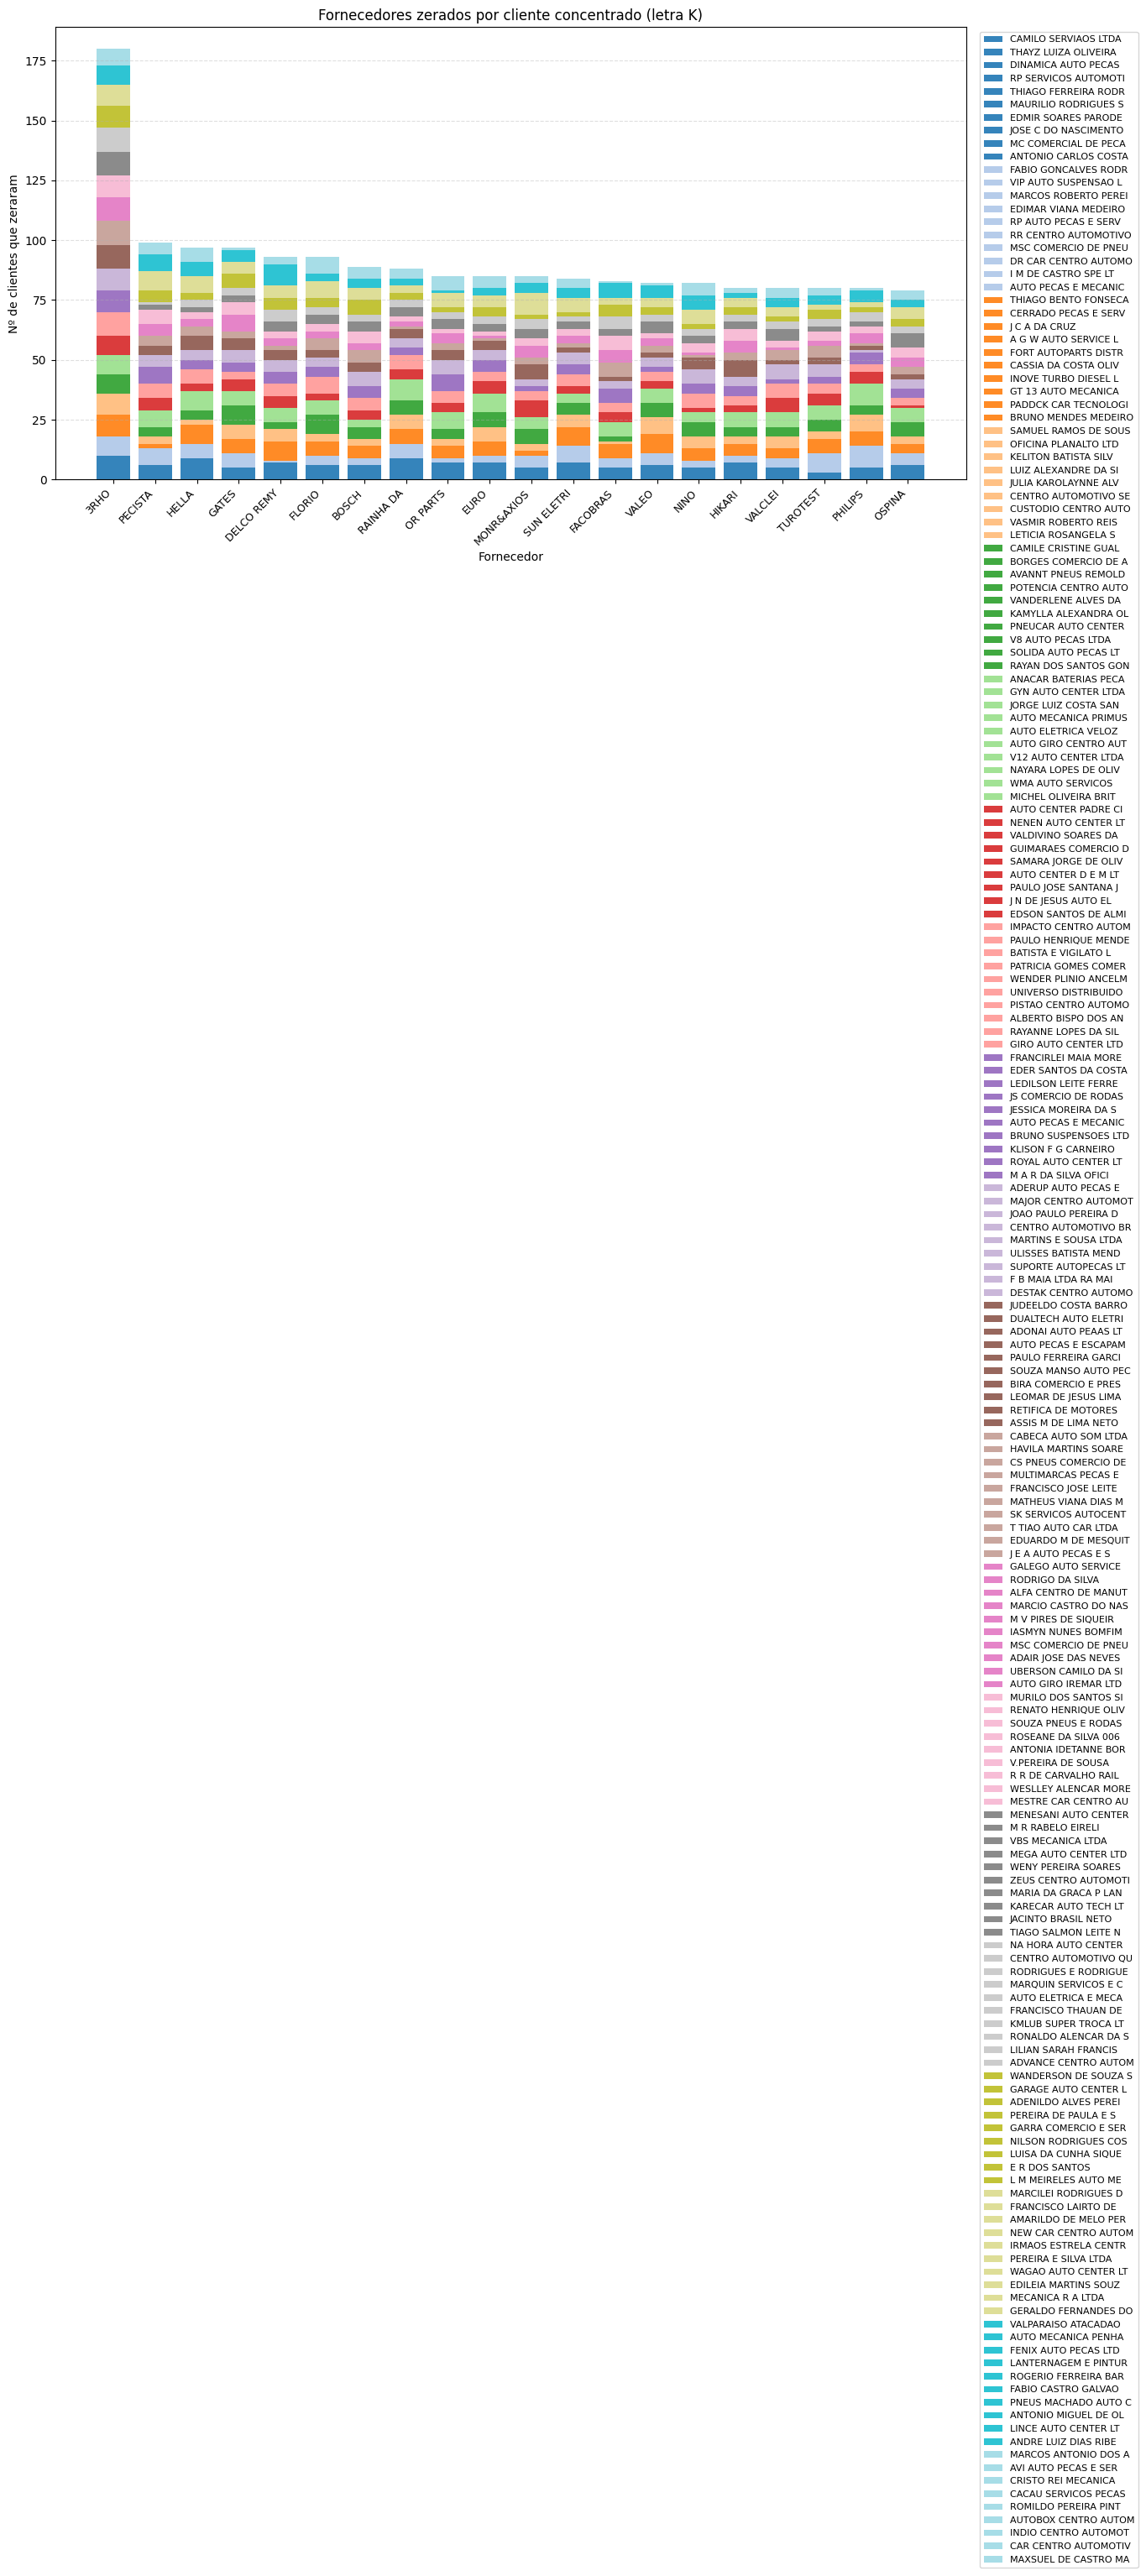

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

top_forn_K = df_comum_K.head(20)['Fornecedor'].tolist()

# Azuis e amarelos bem distintos
cores_lista = [cm.tab20(i / max(len(clientes_concentrados_K), 1)) for i in range(len(clientes_concentrados_K))]
cores_clientes = {cod: cor for cod, cor in zip(clientes_concentrados_K, cores_lista)}

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(top_forn_K))
for cod in clientes_concentrados_K:
    sub = cf_80_K[cf_80_K['codcli'].astype(str) == cod]
    nome = sub['nome'].iloc[0][:20]
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    valores = [1 if f in zerados else 0 for f in top_forn_K]
    
    ax.bar(top_forn_K, valores, bottom=bottom,
           color=cores_clientes[cod], label=nome, alpha=0.9)
    bottom += np.array(valores)

ax.set_xlabel("Fornecedor")
ax.set_ylabel("Nº de clientes que zeraram")
ax.set_title("Fornecedores zerados por cliente concentrado (letra K)", fontsize=12)
ax.set_xticklabels(top_forn_Q, rotation=45, ha='right', fontsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()